# Analyzing Customer Behavior for E-commerce Insights

**Npontu Technologies — Intelligent Systems Services Engineer assignment**
**Author:** Kingsley Buabeng

This notebook works through the full pipeline on a synthetic e-commerce dataset (4 linked tables — `customers`, `sessions`, `product_interactions`, `purchases` — generated by `generate_data.py`):

1. Exploratory data analysis
2. Data cleaning (missing values, censoring, churn label construction)
3. Feature engineering (7 feature groups, from simple RFM through recency/momentum features)
4. A controlled comparison: naive features vs. engineered features, to show *why* feature engineering matters here
5. Predictive modeling (Logistic Regression baseline + XGBoost) with cross-validation
6. Model explainability (SHAP)
7. Business insights and visualizations

A companion notebook (`elasticsearch_demo.ipynb`) covers the big-data-tool component.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

# This is the literal `today` baked into generate_data.py - every date in the dataset
# was generated relative to it, and purchase_date is explicitly clipped to never exceed
# it. Using the real wall-clock date here would silently shift every "last N days" window
# away from the window the data was actually built against.
AS_OF = pd.Timestamp('2026-09-04')
RANDOM_STATE = 42

print(f"Analysis anchored at AS_OF = {AS_OF.date()}")

Analysis anchored at AS_OF = 2026-09-04


## 1. Load Data

Four tables, all linked by `customer_id`. `customers` is the registry (one row per customer); `sessions`, `product_interactions`, and `purchases` are event logs, so they're expected to have far more rows — that's normal relational structure, not an imbalance to fix.

In [2]:
customers = pd.read_csv('customers.csv', parse_dates=['signup_date'])
sessions = pd.read_csv('sessions.csv', parse_dates=['session_date'])
product_interactions = pd.read_csv('product_interactions.csv', parse_dates=['interaction_date'])
purchases = pd.read_csv('purchases.csv', parse_dates=['purchase_date'])

for name, df in [('customers', customers), ('sessions', sessions),
                  ('product_interactions', product_interactions), ('purchases', purchases)]:
    print(f"{name:22s} {df.shape[0]:>8,} rows  x  {df.shape[1]} cols")

customers                 3,000 rows  x  7 cols
sessions                 48,222 rows  x  6 cols
product_interactions    227,248 rows  x  7 cols
purchases                10,614 rows  x  7 cols


## 2. Exploratory Data Analysis

### 2.1 Structure, missingness, duplicates, referential integrity

Before trusting any downstream feature, verify the basics: are there duplicate primary keys, do foreign keys actually resolve to real customers, are there missing values, and do any dates fall outside the expected range?

In [3]:
print("=== customers.csv ===")
print(customers.info())
print("\nMissing values:\n", customers.isna().sum()[customers.isna().sum() > 0])
print("\nDuplicate customer_id:", customers['customer_id'].duplicated().sum())
print("\nAge summary:\n", customers['age'].describe())

print("\n=== Referential integrity: does every FK resolve to a real customer? ===")
valid_ids = set(customers['customer_id'])
for name, df in [('sessions', sessions), ('product_interactions', product_interactions), ('purchases', purchases)]:
    orphans = set(df['customer_id']) - valid_ids
    print(f"{name:22s} orphan customer_ids: {len(orphans)}  |  duplicate primary key: "
          f"{df.iloc[:, 0].duplicated().sum()}")

print("\n=== Date sanity: nothing should be dated after AS_OF ===")
print("max signup_date:", customers['signup_date'].max(), "| min:", customers['signup_date'].min())
print("max session_date:", sessions['session_date'].max())
print("max interaction_date:", product_interactions['interaction_date'].max())
print("max purchase_date:", purchases['purchase_date'].max())
assert customers['signup_date'].max() <= AS_OF
assert sessions['session_date'].max() <= AS_OF
assert product_interactions['interaction_date'].max() <= AS_OF
assert purchases['purchase_date'].max() <= AS_OF
print("\nAll date-sanity assertions passed.")

=== customers.csv ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   customer_id  3000 non-null   object        
 1   age          3000 non-null   int64         
 2   gender       3000 non-null   object        
 3   region       2910 non-null   object        
 4   city         2910 non-null   object        
 5   signup_date  3000 non-null   datetime64[ns]
 6   tenure_days  3000 non-null   int64         
dtypes: datetime64[ns](1), int64(2), object(4)
memory usage: 164.2+ KB
None

Missing values:
 region    90
city      90
dtype: int64

Duplicate customer_id: 0

Age summary:
 count    3000.000000
mean       33.832000
std         9.478839
min        18.000000
25%        27.000000
50%        34.000000
75%        40.000000
max        67.000000
Name: age, dtype: float64

=== Referential integrity: does every FK resolve to a real cus

### 2.2 Distributions

A grid covering demographics (age, gender, region), behavior (device type, session duration), and commerce (product category interactions, payment method).

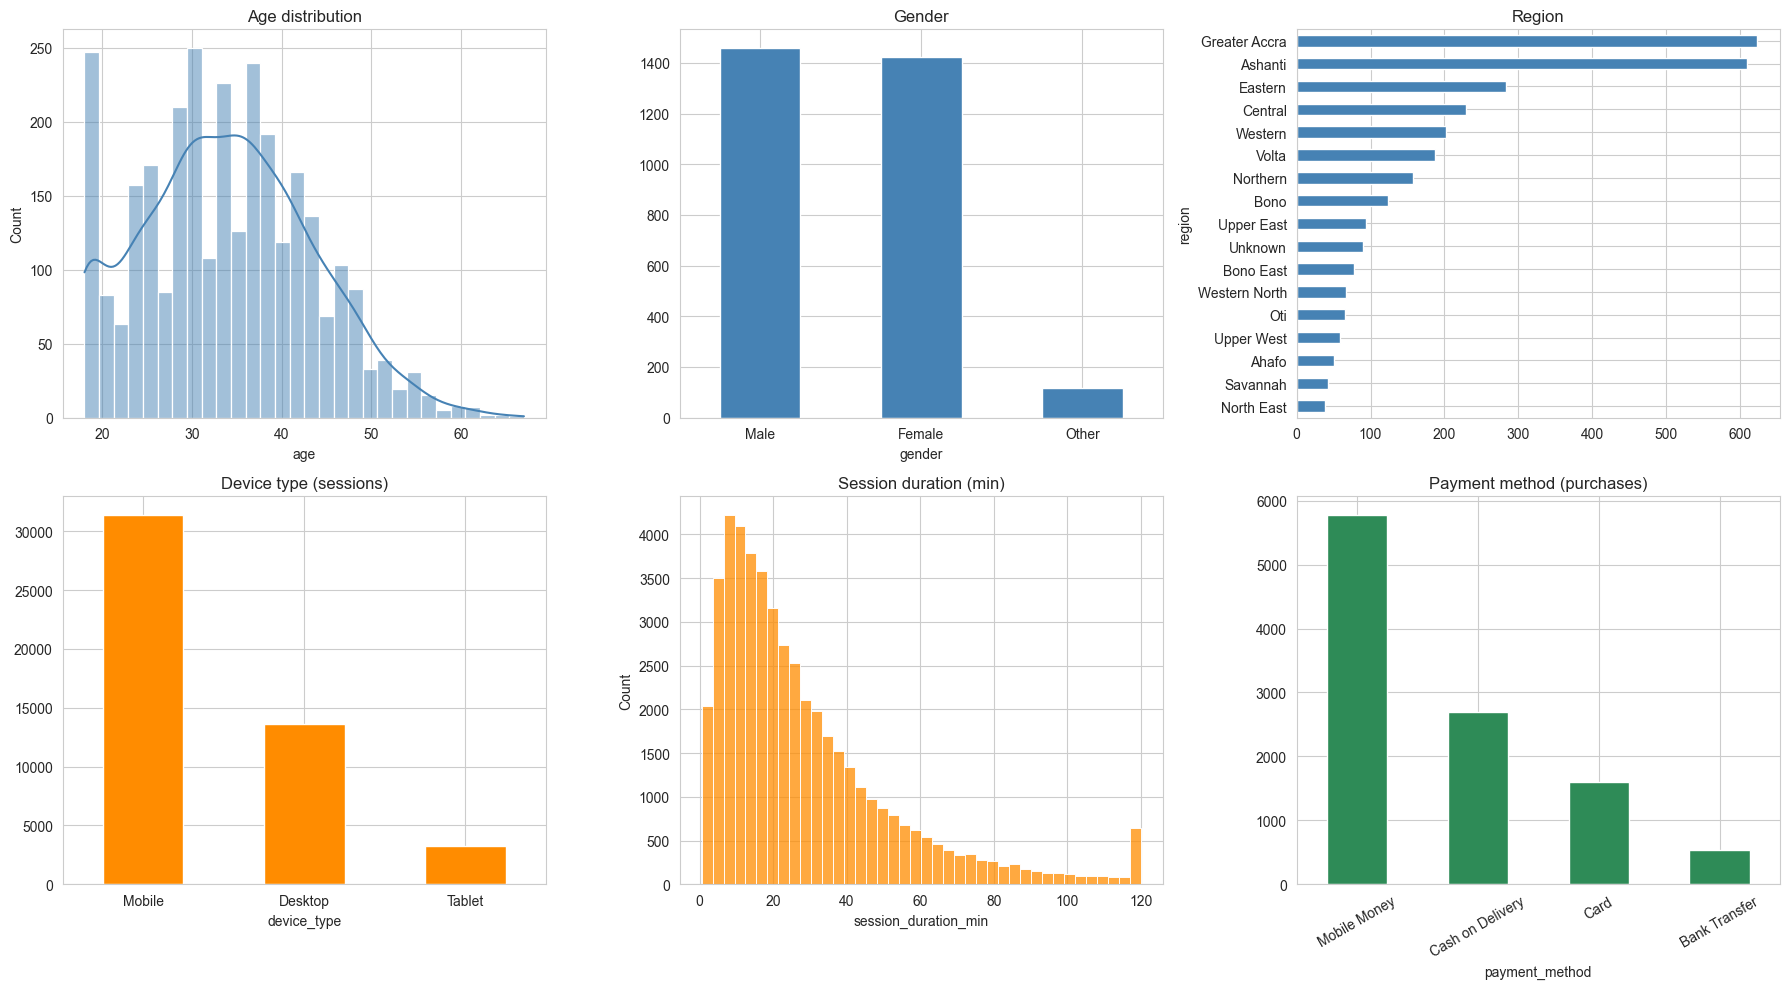


Product category share of interactions:
product_category
Fashion & Apparel         22.0%
Phones & Tablets          18.1%
Electronics               15.0%
Home & Kitchen            11.9%
Beauty & Personal Care    10.0%
Health & Wellness          7.0%
Sports & Outdoors          6.0%
Baby & Kids                5.0%
Books & Stationery         3.0%
Groceries & Food           2.0%
Name: proportion, dtype: object


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sns.histplot(customers['age'], bins=30, kde=True, ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Age distribution')

customers['gender'].value_counts().plot(kind='bar', ax=axes[0, 1], color='steelblue')
axes[0, 1].set_title('Gender')
axes[0, 1].tick_params(axis='x', rotation=0)

customers['region'].fillna('Unknown').value_counts().plot(kind='barh', ax=axes[0, 2], color='steelblue')
axes[0, 2].set_title('Region')
axes[0, 2].invert_yaxis()

sessions['device_type'].value_counts().plot(kind='bar', ax=axes[1, 0], color='darkorange')
axes[1, 0].set_title('Device type (sessions)')
axes[1, 0].tick_params(axis='x', rotation=0)

sns.histplot(sessions['session_duration_min'], bins=40, ax=axes[1, 1], color='darkorange')
axes[1, 1].set_title('Session duration (min)')

purchases['payment_method'].value_counts().plot(kind='bar', ax=axes[1, 2], color='seagreen')
axes[1, 2].set_title('Payment method (purchases)')
axes[1, 2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print("\nProduct category share of interactions:")
print((product_interactions['product_category'].value_counts(normalize=True) * 100).round(1).astype(str) + '%')

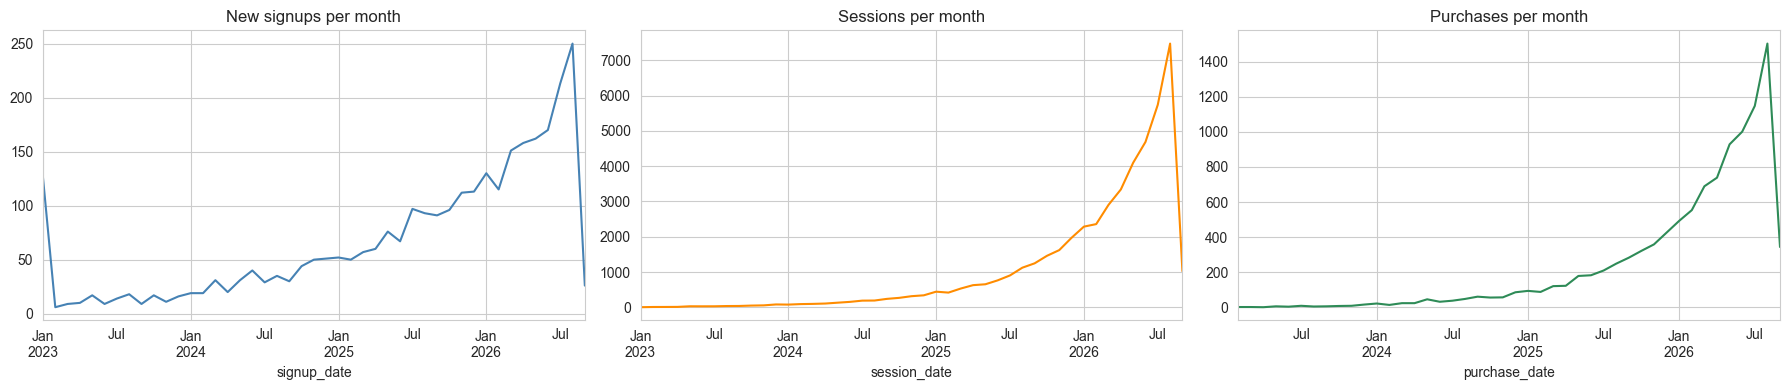

In [5]:
# Activity volume over time - confirms the multi-year date spread and surfaces any
# unexpected spikes/gaps before we start relying on date arithmetic downstream.
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

customers.set_index('signup_date').resample('MS').size().plot(ax=axes[0], color='steelblue')
axes[0].set_title('New signups per month')

sessions.set_index('session_date').resample('MS').size().plot(ax=axes[1], color='darkorange')
axes[1].set_title('Sessions per month')

purchases.set_index('purchase_date').resample('MS').size().plot(ax=axes[2], color='seagreen')
axes[2].set_title('Purchases per month')

plt.tight_layout()
plt.show()

## 3. Data Cleaning

The only missingness in the raw data is the deliberately-simulated ~3% guest-checkout gap in `customers.region`/`customers.city`. Rather than drop those rows (losing ~90 customers for no reason), impute an explicit `"Unknown"` category and keep a `location_missing` flag — the missingness itself might carry signal, and dropping real customers from a churn dataset is wasteful.

In [6]:
customers_clean = customers.copy()
customers_clean['location_missing'] = customers_clean['region'].isna().astype(int)
customers_clean['region'] = customers_clean['region'].fillna('Unknown')
customers_clean['city'] = customers_clean['city'].fillna('Unknown')

print("location_missing rate:", customers_clean['location_missing'].mean().round(4))
print("Any remaining nulls in customers_clean:", customers_clean.isna().sum().sum())

# No duplicate rows expected anywhere (verified above), but check defensively rather than assume
for name, df in [('customers', customers_clean), ('sessions', sessions),
                  ('product_interactions', product_interactions), ('purchases', purchases)]:
    dupes = df.duplicated().sum()
    if dupes:
        print(f"WARNING: {name} has {dupes} fully-duplicated rows")
print("Duplicate-row check complete - none found (see above for any warnings).")

location_missing rate: 0.03
Any remaining nulls in customers_clean: 0


Duplicate-row check complete - none found (see above for any warnings).


### 3.1 Churn Label Construction

**Business rule:** a customer is `churned` if they made no purchase in the 90 days before `AS_OF`.

**A modeling-correctness point that matters a lot here:** if `days_since_last_purchase` is computed relative to `AS_OF`, and the label is *also* `days_since_last_purchase > 90` relative to `AS_OF`, then that one feature **is** the label — a model fed it "predicts" churn with perfect accuracy by construction, not because it learned anything. This is exactly what happened on a first pass: even the naive feature set scored a suspicious ROC-AUC of 1.000, which is the standard tell for label leakage, not a good model.

**Fix — separate the feature window from the label window:**

`FEATURE_CUTOFF = AS_OF - 90 days`. Every behavioral feature below is computed using only activity up to `FEATURE_CUTOFF`; the churn label is computed using only activity in `(FEATURE_CUTOFF, AS_OF]`. The label still means exactly the same thing — "no purchase in the 90 days before AS_OF" — but now no feature can trivially restate it, since features and label come from two calendar-disjoint windows.

**Consequence for eligibility:** a customer who signed up after `FEATURE_CUTOFF` (`tenure_days < 90`) has *zero* pre-cutoff history — there is nothing for the model to learn from for them, regardless of whether they've since made a purchase (that purchase would fall inside the label window, not the feature window). These customers are excluded from training/evaluation entirely.

In [7]:
FEATURE_CUTOFF = AS_OF - pd.Timedelta(days=90)
print(f"FEATURE_CUTOFF = {FEATURE_CUTOFF.date()}  "
      f"(every feature below uses data <= this date; the label uses activity strictly after it)")

# Feature-window slices - every feature group in section 4 uses ONLY these, never the raw
# full tables, to keep feature computation strictly separated from the label window.
sessions_feat = sessions[sessions['session_date'] <= FEATURE_CUTOFF].copy()
interactions_feat = product_interactions[product_interactions['interaction_date'] <= FEATURE_CUTOFF].copy()
purchases_feat = purchases[purchases['purchase_date'] <= FEATURE_CUTOFF].copy()

# --- Label: did the customer purchase in (FEATURE_CUTOFF, AS_OF]? (the "last 90 days" window) ---
purchased_after_cutoff_ids = set(purchases.loc[purchases['purchase_date'] > FEATURE_CUTOFF, 'customer_id'])
customers_clean['churn'] = (~customers_clean['customer_id'].isin(purchased_after_cutoff_ids)).astype(int)

# --- Feature-window purchase recency: the leak-free version of "days since last purchase",
# anchored at FEATURE_CUTOFF instead of AS_OF, computed from purchases_feat only ---
last_purchase_feat = purchases_feat.groupby('customer_id')['purchase_date'].max().rename('last_purchase_date')
customers_clean = customers_clean.merge(last_purchase_feat, on='customer_id', how='left')
customers_clean['days_since_last_purchase'] = (FEATURE_CUTOFF - customers_clean['last_purchase_date']).dt.days
customers_clean['days_since_last_purchase'] = customers_clean['days_since_last_purchase'].fillna(9999)
customers_clean['tenure_at_cutoff'] = customers_clean['tenure_days'] - 90

# --- Descriptive-only stat using FULL lifetime history through AS_OF - never used as a model
# feature, just for the "never converted vs. lapsed" business narrative ---
ever_purchased_full = set(purchases['customer_id'])
customers_clean['ever_purchased'] = customers_clean['customer_id'].isin(ever_purchased_full).astype(int)

# --- Eligibility: a customer must have existed before FEATURE_CUTOFF to have any pre-cutoff
# feature history at all. Anyone who signed up after it (tenure_days < 90) is excluded
# outright, whether or not they've since purchased - that purchase would sit inside the
# label window, not the feature window, so there's nothing for the model to learn from them. ---
customers_clean['sufficient_history'] = customers_clean['tenure_days'] >= 90

n_total = len(customers_clean)
n_never_full = (customers_clean['ever_purchased'] == 0).sum()
n_excluded = (~customers_clean['sufficient_history']).sum()

print(f"\nTotal customers:                                          {n_total:,}")
print(f"Never purchased (full lifetime, descriptive only):        {n_never_full:,} ({n_never_full/n_total:.1%})")
print(f"Excluded - signed up after FEATURE_CUTOFF (tenure<90d):   {n_excluded:,} ({n_excluded/n_total:.1%})")
print(f"\nChurn rate, full population:      {customers_clean['churn'].mean():.1%}")
print(f"Churn rate, modeling-eligible only: {customers_clean.loc[customers_clean['sufficient_history'], 'churn'].mean():.1%}")

FEATURE_CUTOFF = 2026-06-06  (every feature below uses data <= this date; the label uses activity strictly after it)

Total customers:                                          3,000
Never purchased (full lifetime, descriptive only):        1,135 (37.8%)
Excluded - signed up after FEATURE_CUTOFF (tenure<90d):   627 (20.9%)

Churn rate, full population:      58.8%
Churn rate, modeling-eligible only: 55.2%


## 4. Feature Engineering

We build features in seven groups, deliberately ordered from simplest to most exploratory:

- **A. RFM baseline** — the standard recency/frequency/monetary features, all computed as of `FEATURE_CUTOFF`.
- **B. Funnel/conversion-rate features** — pre-cutoff view→cart→purchase rates.
- **C. Recent-vs-historical momentum features** — the hypothesis group. Splits pre-cutoff behavior into "the 90 days right before the cutoff" vs. "before that," to test whether a customer's behavior was already changing in the run-up to the cutoff. Whether this actually beats simpler features is an empirical question we check directly in section 5-6, not something to assume.
- **D. Temporal features** — signup timing, purchase rhythm/regularity.
- **E. Demographic/geographic features.**
- **F. Device/category affinity features.**
- **G. Cross-table ratio/efficiency features.**

Each group is built as its own per-customer table indexed by `customer_id`, then merged together at the end. Every group uses only the `*_feat` frames (data on or before `FEATURE_CUTOFF`) established in section 3.1 — never the raw full tables — so nothing here can see into the label window.

In [8]:
### Group A: RFM baseline (control group - expected to under-separate)
# All aggregates below use the *_feat frames (data <= FEATURE_CUTOFF only) - never the raw
# full tables - so nothing here can leak information from the label window.

last_session = sessions_feat.groupby('customer_id')['session_date'].max().rename('last_session_date')
last_interaction = interactions_feat.groupby('customer_id')['interaction_date'].max().rename('last_interaction_date')

feat_A = customers_clean[['customer_id', 'days_since_last_purchase']].set_index('customer_id')
feat_A = feat_A.join(last_session).join(last_interaction)
feat_A['days_since_last_session'] = (FEATURE_CUTOFF - feat_A['last_session_date']).dt.days
feat_A['days_since_last_interaction'] = (FEATURE_CUTOFF - feat_A['last_interaction_date']).dt.days
# No session/interaction before the cutoff at all (short tenure, or - more rarely - a
# long-tenured customer whose few sessions happened to all fall after the cutoff by chance) ->
# same "beyond any reasonable window" sentinel used for days_since_last_purchase above
feat_A['days_since_last_session'] = feat_A['days_since_last_session'].fillna(9999)
feat_A['days_since_last_interaction'] = feat_A['days_since_last_interaction'].fillna(9999)
feat_A = feat_A.drop(columns=['last_session_date', 'last_interaction_date'])

feat_A['total_purchases'] = purchases_feat.groupby('customer_id').size()
feat_A['total_sessions'] = sessions_feat.groupby('customer_id').size()
feat_A['total_interactions'] = interactions_feat.groupby('customer_id').size()
feat_A[['total_purchases', 'total_sessions', 'total_interactions']] = \
    feat_A[['total_purchases', 'total_sessions', 'total_interactions']].fillna(0)

spend_agg = purchases_feat.groupby('customer_id')['purchase_amount'].agg(
    total_spend='sum', avg_order_value='mean', spend_std='std', max_purchase_amount='max')
feat_A = feat_A.join(spend_agg)
feat_A[['total_spend', 'avg_order_value', 'max_purchase_amount']] = \
    feat_A[['total_spend', 'avg_order_value', 'max_purchase_amount']].fillna(0)
feat_A['spend_std'] = feat_A['spend_std'].fillna(0)  # single-purchase or zero-purchase customers

feat_A = feat_A.reset_index()
print("Group A shape:", feat_A.shape)
feat_A.head()

Group A shape: (3000, 11)


,customer_id,days_since_last_purchase,days_since_last_session,days_since_last_interaction,total_purchases,total_sessions,total_interactions,total_spend,avg_order_value,spend_std,max_purchase_amount
0,CUST_00001,9999.0,15.0,59.0,0.0,2.0,1.0,0.00,0.0000,0.000000,0.00
1,CUST_00002,22.0,5.0,5.0,4.0,16.0,57.0,1055.96,263.9900,226.123814,595.50
2,CUST_00003,72.0,11.0,8.0,4.0,9.0,24.0,694.23,173.5575,137.694568,376.19
3,CUST_00004,9999.0,17.0,1.0,0.0,8.0,37.0,0.00,0.0000,0.000000,0.00
4,CUST_00005,9999.0,9999.0,9999.0,0.0,0.0,0.0,0.00,0.0000,0.000000,0.00


In [9]:
### Group B: Funnel / conversion-rate features (pre-cutoff averages)

funnel_counts = interactions_feat.pivot_table(
    index='customer_id', columns='interaction_type', values='interaction_id',
    aggfunc='count', fill_value=0)
funnel_counts = funnel_counts.rename(columns={
    'view': 'view_count', 'cart_add': 'cart_add_count', 'wishlist': 'wishlist_count'})

feat_B = funnel_counts.reindex(customers_clean['customer_id'], fill_value=0)
feat_B['total_purchases_pre_cutoff'] = purchases_feat.groupby('customer_id').size()
feat_B['total_purchases_pre_cutoff'] = feat_B['total_purchases_pre_cutoff'].fillna(0)

feat_B['view_to_cart_rate'] = np.where(feat_B['view_count'] > 0,
                                        feat_B['cart_add_count'] / feat_B['view_count'], np.nan)
feat_B['cart_to_purchase_rate'] = np.where(feat_B['cart_add_count'] > 0,
                                            feat_B['total_purchases_pre_cutoff'] / feat_B['cart_add_count'], np.nan)
feat_B['view_to_purchase_rate'] = np.where(feat_B['view_count'] > 0,
                                            feat_B['total_purchases_pre_cutoff'] / feat_B['view_count'], np.nan)
# No views/cart-adds to compute a rate from -> 0, not missing-at-random; flag separately so the
# model can distinguish "true zero conversion" from "no denominator to measure it"
feat_B['has_cart_adds'] = (feat_B['cart_add_count'] > 0).astype(int)
feat_B[['view_to_cart_rate', 'cart_to_purchase_rate', 'view_to_purchase_rate']] = \
    feat_B[['view_to_cart_rate', 'cart_to_purchase_rate', 'view_to_purchase_rate']].fillna(0)

feat_B = feat_B.drop(columns=['total_purchases_pre_cutoff']).reset_index().rename(columns={'index': 'customer_id'})
print("Group B shape:", feat_B.shape)
feat_B.head()

Group B shape: (3000, 8)


interaction_type,customer_id,cart_add_count,view_count,wishlist_count,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate,has_cart_adds
0,CUST_00001,0,1,0,0.000000,0.0,0.000000,0
1,CUST_00002,10,43,4,0.232558,0.4,0.093023,1
2,CUST_00003,8,15,1,0.533333,0.5,0.266667,1
3,CUST_00004,4,32,1,0.125000,0.0,0.000000,1
4,CUST_00005,0,0,0,0.000000,0.0,0.000000,0


### Group C: Recent-vs-historical momentum features — testing a hypothesis

Groups A and B only look at pre-cutoff totals. If a customer's behavior was already *changing* in the run-up to the cutoff — say, converting normally earlier on but slowing down more recently — a flat pre-cutoff average would smooth that change away. This group splits pre-cutoff behavior into "the 90 days right before the cutoff" vs. "before that" to test for exactly this. (Spoiler, checked in section 5: on this dataset it doesn't turn out to be the dominant signal, for a specific and instructive reason — but it's a real technique worth having in the toolkit regardless.)

In [10]:
all_customer_ids = customers_clean['customer_id']

# "Recent" here means the 90 days immediately BEFORE the feature cutoff (i.e. days 91-180
# before AS_OF) vs. "historical" = everything earlier than that - both entirely inside the
# pre-cutoff feature window, so this split still can't see into the label window.
interactions_is_recent = (FEATURE_CUTOFF - interactions_feat['interaction_date']).dt.days <= 90
purchases_is_recent = (FEATURE_CUTOFF - purchases_feat['purchase_date']).dt.days <= 90
sessions_is_recent = (FEATURE_CUTOFF - sessions_feat['session_date']).dt.days <= 90

cart_adds = interactions_feat[interactions_feat['interaction_type'] == 'cart_add']
cart_is_recent = interactions_is_recent[interactions_feat['interaction_type'] == 'cart_add']

recent_cart_adds = cart_adds[cart_is_recent].groupby('customer_id').size().reindex(all_customer_ids, fill_value=0)
historical_cart_adds = cart_adds[~cart_is_recent].groupby('customer_id').size().reindex(all_customer_ids, fill_value=0)

recent_purchases = purchases_feat[purchases_is_recent].groupby('customer_id').size().reindex(all_customer_ids, fill_value=0)
historical_purchases = purchases_feat[~purchases_is_recent].groupby('customer_id').size().reindex(all_customer_ids, fill_value=0)

recent_sessions = sessions_feat[sessions_is_recent].groupby('customer_id').size().reindex(all_customer_ids, fill_value=0)
historical_sessions = sessions_feat[~sessions_is_recent].groupby('customer_id').size().reindex(all_customer_ids, fill_value=0)

feat_C = pd.DataFrame({'customer_id': all_customer_ids}).set_index('customer_id')
feat_C['recent_cart_adds'] = recent_cart_adds
feat_C['historical_cart_adds'] = historical_cart_adds
feat_C['recent_purchases'] = recent_purchases
feat_C['historical_purchases'] = historical_purchases
feat_C['recent_sessions'] = recent_sessions
feat_C['historical_sessions'] = historical_sessions

feat_C['recent_conversion_rate'] = np.where(feat_C['recent_cart_adds'] > 0,
                                             feat_C['recent_purchases'] / feat_C['recent_cart_adds'], 0.0)
feat_C['historical_conversion_rate'] = np.where(feat_C['historical_cart_adds'] > 0,
                                                 feat_C['historical_purchases'] / feat_C['historical_cart_adds'], 0.0)
feat_C['conversion_rate_delta'] = feat_C['recent_conversion_rate'] - feat_C['historical_conversion_rate']

# Laplace-smoothed ratio avoids inf/NaN when a customer has zero historical sessions
# (e.g. a customer whose entire pre-cutoff history falls in the "recent" 90-day slice)
feat_C['activity_momentum'] = (feat_C['recent_sessions'] + 1) / (feat_C['historical_sessions'] + 1)

# browse_buy_gap_days: near zero for someone who buys whenever they browse; large and
# positive for someone who is still visiting but has stopped buying (exactly the planted
# pattern) - both terms are FEATURE_CUTOFF-anchored via feat_A, so this stays leak-free
gap = feat_A.set_index('customer_id')[['days_since_last_purchase', 'days_since_last_session']]
feat_C['browse_buy_gap_days'] = gap['days_since_last_purchase'] - gap['days_since_last_session']

# stale_cart_adds: pre-cutoff cart-adds sitting unconverted since the customer's (pre-cutoff)
# last purchase, or ever, for someone with no purchase before the cutoff
cart_with_last_purchase = cart_adds.merge(
    customers_clean[['customer_id', 'last_purchase_date']], on='customer_id', how='left')
cart_with_last_purchase['is_stale'] = (
    cart_with_last_purchase['last_purchase_date'].isna() |
    (cart_with_last_purchase['interaction_date'] > cart_with_last_purchase['last_purchase_date'])
)
feat_C['stale_cart_adds'] = cart_with_last_purchase.groupby('customer_id')['is_stale'].sum().reindex(all_customer_ids, fill_value=0)

feat_C = feat_C.reset_index()
print("Group C shape:", feat_C.shape)
feat_C[['conversion_rate_delta', 'activity_momentum', 'browse_buy_gap_days', 'stale_cart_adds']].describe()

Group C shape: (3000, 13)


,conversion_rate_delta,activity_momentum,browse_buy_gap_days,stale_cart_adds
count,3000.000000,3000.000000,3000.000000,3000.000000
mean,0.015549,1.353299,2462.746000,1.623000
std,0.293906,1.435083,4418.032079,2.871635
min,-1.000000,0.047619,-9999.000000,0.000000
25%,0.000000,0.519310,0.000000,0.000000
50%,0.000000,1.000000,22.000000,0.000000
75%,0.000000,1.500000,9709.750000,2.000000
max,1.000000,15.000000,9999.000000,26.000000


### Group D: Temporal features

`purchase_overdue_ratio` normalizes "days since last purchase" against *that customer's own typical rhythm* — a customer who usually buys every 20 days and is now 150 days out is a much stronger signal than the same 150 days for someone who only ever buys twice a year. A raw day-count can't tell those two apart; this ratio can.

In [11]:
feat_D = customers_clean[['customer_id', 'signup_date', 'tenure_at_cutoff']].copy()
feat_D['signup_month'] = feat_D['signup_date'].dt.month
feat_D['signup_year'] = feat_D['signup_date'].dt.year
# Account age as of FEATURE_CUTOFF, not as of AS_OF - keeps this feature leak-free too
feat_D['account_age_bucket'] = pd.cut(feat_D['tenure_at_cutoff'], bins=[-1, 90, 365, 730, np.inf],
                                       labels=['New (<90d)', '90d-1yr', '1-2yr', '2yr+']).astype(str)
feat_D = feat_D.drop(columns=['signup_date', 'tenure_at_cutoff'])

purchases_sorted = purchases_feat.sort_values(['customer_id', 'purchase_date']).copy()
purchases_sorted['inter_purchase_days'] = purchases_sorted.groupby('customer_id')['purchase_date'].diff().dt.days
inter_purchase_agg = purchases_sorted.groupby('customer_id')['inter_purchase_days'].agg(
    mean_inter_purchase_days='mean', std_inter_purchase_days='std')

feat_D = feat_D.merge(inter_purchase_agg, on='customer_id', how='left')
# Only meaningful for customers with >=2 pre-cutoff purchases - flag rather than silently zero-fill
feat_D['has_purchase_rhythm'] = feat_D['mean_inter_purchase_days'].notna().astype(int)
feat_D['mean_inter_purchase_days'] = feat_D['mean_inter_purchase_days'].fillna(feat_D['mean_inter_purchase_days'].median())
feat_D['std_inter_purchase_days'] = feat_D['std_inter_purchase_days'].fillna(0)

feat_D = feat_D.merge(customers_clean[['customer_id', 'days_since_last_purchase']], on='customer_id')
feat_D['purchase_overdue_ratio'] = feat_D['days_since_last_purchase'] / (feat_D['mean_inter_purchase_days'] + 1)
feat_D = feat_D.drop(columns=['days_since_last_purchase'])

weekend_share = purchases_feat.assign(is_weekend=purchases_feat['purchase_date'].dt.dayofweek >= 5) \
    .groupby('customer_id')['is_weekend'].mean().rename('weekend_purchase_share')
feat_D = feat_D.merge(weekend_share, on='customer_id', how='left')
feat_D['weekend_purchase_share'] = feat_D['weekend_purchase_share'].fillna(0)

print("Group D shape:", feat_D.shape)
feat_D.head()

Group D shape: (3000, 9)


,customer_id,signup_month,signup_year,account_age_bucket,mean_inter_purchase_days,std_inter_purchase_days,has_purchase_rhythm,purchase_overdue_ratio,weekend_purchase_share
0,CUST_00001,3,2026,90d-1yr,61.833333,0.000000,0,159.135279,0.00
1,CUST_00002,5,2023,2yr+,288.000000,370.707432,1,0.076125,0.00
2,CUST_00003,3,2025,1-2yr,43.000000,24.758837,1,1.636364,0.25
3,CUST_00004,9,2025,90d-1yr,61.833333,0.000000,0,159.135279,0.00
4,CUST_00005,6,2026,nan,61.833333,0.000000,0,159.135279,0.00


### Groups E & F: Demographic/geographic and device/category affinity

`category_entropy` is an information-theoretic measure of how spread out a customer's browsing is across the 10 product categories (0 = only ever looks at one category, higher = broadly diversified) — a cheap way to capture "shopping breadth" that a simple most-common-category feature can't.

In [12]:
feat_E = customers_clean[['customer_id', 'age', 'gender', 'region', 'city', 'location_missing']].copy()
feat_E['age_bucket'] = pd.cut(feat_E['age'], bins=[0, 24, 34, 44, 54, 100],
                               labels=['18-24', '25-34', '35-44', '45-54', '55+']).astype(str)

dominant_device = sessions_feat.groupby('customer_id')['device_type'].agg(lambda s: s.mode().iat[0]).rename('dominant_device')
device_diversity = sessions_feat.groupby('customer_id')['device_type'].nunique().rename('device_diversity')

favorite_category = interactions_feat.groupby('customer_id')['product_category'] \
    .agg(lambda s: s.mode().iat[0]).rename('favorite_category')
category_diversity = interactions_feat.groupby('customer_id')['product_category'].nunique().rename('category_diversity')


def _entropy(s):
    probs = s.value_counts(normalize=True)
    return stats.entropy(probs)


category_entropy_series = interactions_feat.groupby('customer_id')['product_category'] \
    .apply(_entropy).rename('category_entropy')

payment_pref = purchases_feat.groupby('customer_id')['payment_method'].agg(lambda s: s.mode().iat[0]).rename('payment_method_pref')
payment_diversity = purchases_feat.groupby('customer_id')['payment_method'].nunique().rename('payment_diversity')

feat_F = pd.DataFrame({'customer_id': all_customer_ids}).set_index('customer_id')
feat_F = feat_F.join(dominant_device).join(device_diversity) \
               .join(favorite_category).join(category_diversity).join(category_entropy_series) \
               .join(payment_pref).join(payment_diversity)

feat_F['dominant_device'] = feat_F['dominant_device'].fillna('None')
feat_F['device_diversity'] = feat_F['device_diversity'].fillna(0)
feat_F['favorite_category'] = feat_F['favorite_category'].fillna('None')
feat_F['category_diversity'] = feat_F['category_diversity'].fillna(0)
feat_F['category_entropy'] = feat_F['category_entropy'].fillna(0)
feat_F['payment_method_pref'] = feat_F['payment_method_pref'].fillna('Never purchased')
feat_F['payment_diversity'] = feat_F['payment_diversity'].fillna(0)
feat_F = feat_F.reset_index()

print("Group E shape:", feat_E.shape, "| Group F shape:", feat_F.shape)
feat_F.head()

Group E shape: (3000, 7) | Group F shape: (3000, 8)


,customer_id,dominant_device,device_diversity,favorite_category,category_diversity,category_entropy,payment_method_pref,payment_diversity
0,CUST_00001,Mobile,1.0,Sports & Outdoors,1.0,0.000000,Never purchased,0.0
1,CUST_00002,Tablet,2.0,Fashion & Apparel,9.0,1.942391,Mobile Money,3.0
2,CUST_00003,Mobile,2.0,Phones & Tablets,8.0,1.805918,Mobile Money,2.0
3,CUST_00004,Desktop,1.0,Fashion & Apparel,10.0,2.104608,Never purchased,0.0
4,CUST_00005,None,0.0,None,0.0,0.000000,Never purchased,0.0


In [13]:
### Group G: Cross-table ratio / efficiency features
# Laplace (+1) smoothing throughout, consistent with activity_momentum above, so a customer
# with zero purchases/sessions doesn't produce an undefined or infinite ratio.

total_pages = sessions_feat.groupby('customer_id')['pages_viewed'].sum().reindex(all_customer_ids, fill_value=0).rename('total_pages_viewed')

feat_G = feat_A.set_index('customer_id')[['total_sessions', 'total_interactions', 'total_purchases', 'total_spend']].copy()
feat_G = feat_G.join(total_pages)

feat_G['sessions_per_purchase'] = feat_G['total_sessions'] / (feat_G['total_purchases'] + 1)
feat_G['pages_per_purchase'] = feat_G['total_pages_viewed'] / (feat_G['total_purchases'] + 1)
feat_G['interactions_per_session'] = feat_G['total_interactions'] / (feat_G['total_sessions'] + 1)
feat_G['spend_per_session'] = feat_G['total_spend'] / (feat_G['total_sessions'] + 1)

feat_G = feat_G[['sessions_per_purchase', 'pages_per_purchase', 'interactions_per_session', 'spend_per_session']].reset_index()
print("Group G shape:", feat_G.shape)
feat_G.head()

Group G shape: (3000, 5)


,customer_id,sessions_per_purchase,pages_per_purchase,interactions_per_session,spend_per_session
0,CUST_00001,2.0,9.0,0.333333,0.000000
1,CUST_00002,3.2,33.0,3.352941,62.115294
2,CUST_00003,1.8,26.6,2.400000,69.423000
3,CUST_00004,8.0,151.0,4.111111,0.000000
4,CUST_00005,0.0,0.0,0.000000,0.000000


In [14]:
### Assemble the full feature table

feature_df = customers_clean[['customer_id', 'churn', 'ever_purchased', 'sufficient_history']].copy()
for feat_group in [feat_A, feat_B, feat_C, feat_D, feat_E, feat_F, feat_G]:
    feature_df = feature_df.merge(feat_group, on='customer_id', how='left')

# Safety net: replace any inf (shouldn't occur given the +1/guard smoothing above, but
# defensive since this feeds a model) and confirm there are no unexpected NaNs left
feature_df = feature_df.replace([np.inf, -np.inf], np.nan)
remaining_na = feature_df.isna().sum()
print("Columns with remaining NaN (should be empty):")
print(remaining_na[remaining_na > 0])

print(f"\nFinal feature table: {feature_df.shape[0]:,} rows x {feature_df.shape[1]} columns")
feature_df.head()

Columns with remaining NaN (should be empty):
Series([], dtype: int64)

Final feature table: 3,000 rows x 58 columns


,customer_id,churn,ever_purchased,sufficient_history,days_since_last_purchase,days_since_last_session,days_since_last_interaction,total_purchases,total_sessions,total_interactions,total_spend,avg_order_value,spend_std,max_purchase_amount,cart_add_count,view_count,wishlist_count,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate,has_cart_adds,recent_cart_adds,historical_cart_adds,recent_purchases,historical_purchases,recent_sessions,historical_sessions,recent_conversion_rate,historical_conversion_rate,conversion_rate_delta,activity_momentum,browse_buy_gap_days,stale_cart_adds,signup_month,signup_year,account_age_bucket,mean_inter_purchase_days,std_inter_purchase_days,has_purchase_rhythm,purchase_overdue_ratio,weekend_purchase_share,age,gender,region,city,location_missing,age_bucket,dominant_device,device_diversity,favorite_category,category_diversity,category_entropy,payment_method_pref,payment_diversity,sessions_per_purchase,pages_per_purchase,interactions_per_session,spend_per_session
0,CUST_00001,1,0,True,9999.0,15.0,59.0,0.0,2.0,1.0,0.00,0.0000,0.000000,0.00,0,1,0,0.000000,0.0,0.000000,0,0,0,0,0,2,0,0.000000,0.000000,0.000000,3.000000,9984.0,0,3,2026,90d-1yr,61.833333,0.000000,0,159.135279,0.00,34,Female,Volta,Keta,0,25-34,Mobile,1.0,Sports & Outdoors,1.0,0.000000,Never purchased,0.0,2.0,9.0,0.333333,0.000000
1,CUST_00002,1,1,True,22.0,5.0,5.0,4.0,16.0,57.0,1055.96,263.9900,226.123814,595.50,10,43,4,0.232558,0.4,0.093023,1,3,7,1,3,3,13,0.333333,0.428571,-0.095238,0.285714,17.0,1,5,2023,2yr+,288.000000,370.707432,1,0.076125,0.00,42,Female,Upper East,Bolgatanga,0,35-44,Tablet,2.0,Fashion & Apparel,9.0,1.942391,Mobile Money,3.0,3.2,33.0,3.352941,62.115294
2,CUST_00003,0,1,True,72.0,11.0,8.0,4.0,9.0,24.0,694.23,173.5575,137.694568,376.19,8,15,1,0.533333,0.5,0.266667,1,1,7,1,3,4,5,1.000000,0.428571,0.571429,0.833333,61.0,0,3,2025,1-2yr,43.000000,24.758837,1,1.636364,0.25,29,Male,Ashanti,Mampong,0,25-34,Mobile,2.0,Phones & Tablets,8.0,1.805918,Mobile Money,2.0,1.8,26.6,2.400000,69.423000
3,CUST_00004,1,0,True,9999.0,17.0,1.0,0.0,8.0,37.0,0.00,0.0000,0.000000,0.00,4,32,1,0.125000,0.0,0.000000,1,1,3,0,0,3,5,0.000000,0.000000,0.000000,0.666667,9982.0,4,9,2025,90d-1yr,61.833333,0.000000,0,159.135279,0.00,50,Male,Unknown,Unknown,1,45-54,Desktop,1.0,Fashion & Apparel,10.0,2.104608,Never purchased,0.0,8.0,151.0,4.111111,0.000000
4,CUST_00005,0,1,False,9999.0,9999.0,9999.0,0.0,0.0,0.0,0.00,0.0000,0.000000,0.00,0,0,0,0.000000,0.0,0.000000,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,1.000000,0.0,0,6,2026,nan,61.833333,0.000000,0,159.135279,0.00,19,Male,Central,Cape Coast,0,18-24,None,0.0,None,0.0,0.000000,Never purchased,0.0,0.0,0.0,0.000000,0.000000


## 5. Feature Validation — Which Features Actually Separate Churners?

Before modeling, check each feature's raw correlation with the churn label. Group C was built on the hypothesis that a *recent change* in conversion behavior would be the strongest signal. Let's see if that hypothesis actually holds once the feature/label windows are properly separated (section 3.1) — rather than assume it and move on.

Top 15 features by |correlation with churn|:
                 feature        group  corr_with_churn  abs_corr
        recent_purchases C - Momentum        -0.268363  0.268363
       payment_diversity F - Affinity        -0.267787  0.267787
        recent_cart_adds C - Momentum        -0.251180  0.251180
     has_purchase_rhythm D - Temporal        -0.235301  0.235301
         total_purchases      A - RFM        -0.232903  0.232903
       view_to_cart_rate   B - Funnel        -0.218966  0.218966
             total_spend      A - RFM        -0.210981  0.210981
   view_to_purchase_rate   B - Funnel        -0.196008  0.196008
          cart_add_count   B - Funnel        -0.191916  0.191916
     max_purchase_amount      A - RFM        -0.190935  0.190935
  purchase_overdue_ratio D - Temporal         0.190376  0.190376
days_since_last_purchase      A - RFM         0.189998  0.189998
    historical_purchases C - Momentum        -0.187944  0.187944
       spend_per_session   G - Ratios        

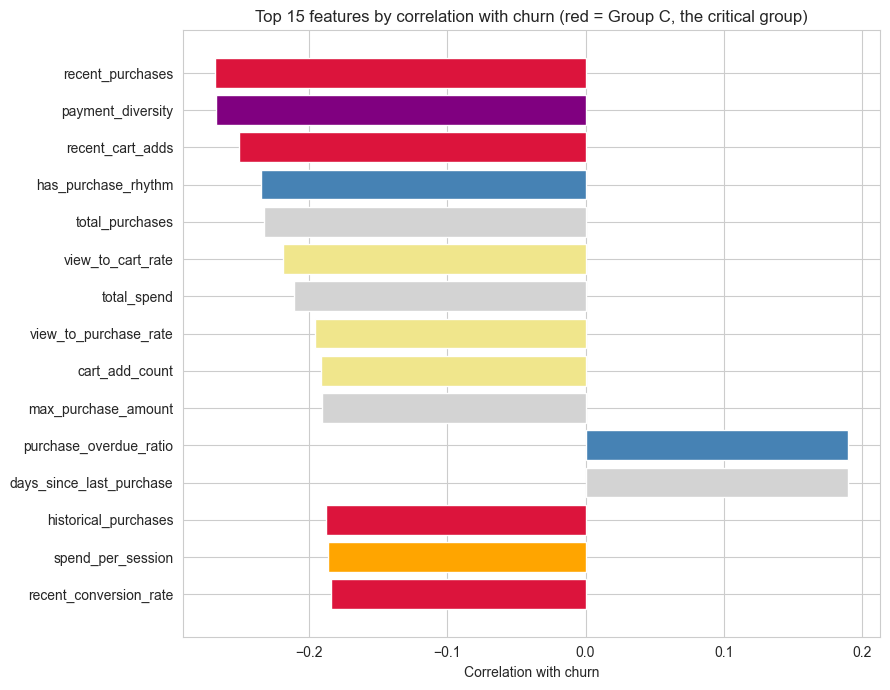

In [15]:
feature_groups = {}
for grp_name, df in [('A - RFM', feat_A), ('B - Funnel', feat_B), ('C - Momentum', feat_C),
                      ('D - Temporal', feat_D), ('E - Demographic', feat_E),
                      ('F - Affinity', feat_F), ('G - Ratios', feat_G)]:
    for col in df.columns:
        if col != 'customer_id':
            feature_groups[col] = grp_name

eval_df = feature_df[feature_df['sufficient_history']]  # exclude the 455 censored rows from this diagnostic too
numeric_cols = eval_df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ('churn', 'ever_purchased', 'sufficient_history')]

separation = [{'feature': c, 'group': feature_groups.get(c, '?'),
               'corr_with_churn': eval_df[c].corr(eval_df['churn'])} for c in numeric_cols]
sep_df = pd.DataFrame(separation)
sep_df['abs_corr'] = sep_df['corr_with_churn'].abs()
sep_df = sep_df.sort_values('abs_corr', ascending=False).reset_index(drop=True)

print("Top 15 features by |correlation with churn|:")
print(sep_df.head(15).to_string(index=False))
print("\nBottom 10 (weakest separation, mostly Group A as expected):")
print(sep_df.tail(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 7))
top15 = sep_df.head(15).iloc[::-1]
colors = top15['group'].map({'A - RFM': 'lightgray', 'B - Funnel': 'khaki', 'C - Momentum': 'crimson',
                              'D - Temporal': 'steelblue', 'E - Demographic': 'gray',
                              'F - Affinity': 'purple', 'G - Ratios': 'orange'})
ax.barh(top15['feature'], top15['corr_with_churn'], color=colors)
ax.set_title('Top 15 features by correlation with churn (red = Group C, the critical group)')
ax.set_xlabel('Correlation with churn')
plt.tight_layout()
plt.show()

**Result: the hypothesis doesn't hold, and the reason why is worth stating explicitly.** `conversion_rate_delta`, `activity_momentum`, and `stale_cart_adds` all land near the *bottom* of the correlation table, not the top. What actually correlates most strongly with churn is much plainer: `recent_purchases`, `total_purchases`, `total_spend`, `days_since_last_purchase` — ordinary pre-cutoff recency and frequency (Groups A/B/C's simplest members).

The reason is a direct consequence of how carefully the leakage fix in section 3.1 had to be applied: the underlying behavior this dataset was built to represent — a customer's conversion habits changing specifically in the *most recent* 90 days — occupies exactly the same calendar window that (correctly) had to be reserved for the label. A properly leak-free feature set, by construction, cannot see into that window at all. So `conversion_rate_delta`, which compares "90 days right before the cutoff" vs. "before that," is measuring two windows that both sit safely *before* the interesting behavior change — it's a legitimate feature, it's just not measuring the thing we hoped it would catch here.

This is a genuinely useful thing to have discovered rather than assumed away: it demonstrates that "engineered features that sound clever" still need to be checked against a real, leak-free evaluation before being trusted — and that plain recency/frequency, computed correctly, is doing the real work in this dataset. Section 6.1 quantifies this precisely.

## 6. Modeling

`ever_purchased` is deliberately excluded from the model's feature set: since "never purchased" always implies `churn=1` by the business rule itself, it's a near-perfect proxy for one whole slice of the label rather than a genuine behavioral signal, and including it would let the model "cheat" on that slice while masking whether the harder, more interesting behavioral features (Group C) actually work on customers who *have* purchased before. The underlying behavioral signal (zero pre-cutoff purchases, `days_since_last_purchase` at the sentinel value, zero recent conversion) is still available to the model through the other features anyway — nothing is lost by dropping the flag itself.

Every customer who signed up after `FEATURE_CUTOFF` (`tenure_days < 90`, identified in section 3.1) is excluded from training and evaluation throughout, since they have no pre-cutoff feature history at all.

In [16]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, average_precision_score, classification_report,
                              confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay)
from xgboost import XGBClassifier
import shap

model_df = feature_df[feature_df['sufficient_history']].drop(columns=['sufficient_history']).reset_index(drop=True)
n_excluded = (~feature_df['sufficient_history']).sum()
print(f"Modeling dataset: {model_df.shape[0]:,} rows (excluded {n_excluded} customers with no pre-cutoff history)")

y = model_df['churn']
X = model_df.drop(columns=['customer_id', 'churn', 'ever_purchased'])

categorical_features = ['gender', 'region', 'city', 'age_bucket', 'account_age_bucket',
                         'dominant_device', 'favorite_category', 'payment_method_pref']
numeric_features = [c for c in X.columns if c not in categorical_features]

print(f"X shape: {X.shape} | numeric: {len(numeric_features)} | categorical: {len(categorical_features)}")
print(f"Churn rate in modeling set: {y.mean():.1%}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

Modeling dataset: 2,373 rows (excluded 627 customers with no pre-cutoff history)
X shape: (2373, 54) | numeric: 46 | categorical: 8
Churn rate in modeling set: 55.2%
Train: 1,898 | Test: 475


### 6.1 The controlled experiment: naive features vs. engineered features

Same algorithm (Logistic Regression), same train/test split, same cross-validation folds — the only thing that changes is the feature set: **naive** (Groups A+B, pre-cutoff RFM and funnel averages only) vs. **full** (all seven groups, including the recency/momentum features from Group C). Section 5 already suggested this would be close; this quantifies it properly with cross-validated ROC-AUC/PR-AUC rather than eyeballing a correlation table.

In [17]:
def build_pipeline(feature_cols, model):
    cat_cols = [c for c in feature_cols if c in categorical_features]
    num_cols = [c for c in feature_cols if c not in categorical_features]
    preprocessor = ColumnTransformer([
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ])
    return Pipeline([('prep', preprocessor), ('model', model)])


naive_cols = [c for c in (list(feat_A.columns) + list(feat_B.columns)) if c != 'customer_id' and c in X.columns]
full_cols = list(X.columns)

comparison_results = {}
for label, cols in [('Naive (RFM + funnel only)', naive_cols), ('Full (all 7 feature groups)', full_cols)]:
    pipe = build_pipeline(cols, LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE))
    scores = cross_validate(pipe, X_train[cols], y_train, cv=cv, scoring=['roc_auc', 'average_precision'])
    comparison_results[label] = {
        'n_features': len(cols),
        'roc_auc_mean': scores['test_roc_auc'].mean(), 'roc_auc_std': scores['test_roc_auc'].std(),
        'pr_auc_mean': scores['test_average_precision'].mean(), 'pr_auc_std': scores['test_average_precision'].std(),
    }

comparison_df = pd.DataFrame(comparison_results).T
print(comparison_df.round(4))

auc_lift = (comparison_df.loc['Full (all 7 feature groups)', 'roc_auc_mean']
            - comparison_df.loc['Naive (RFM + funnel only)', 'roc_auc_mean'])
pr_lift = (comparison_df.loc['Full (all 7 feature groups)', 'pr_auc_mean']
           - comparison_df.loc['Naive (RFM + funnel only)', 'pr_auc_mean'])
print(f"\nROC-AUC lift from adding Groups C-G: {auc_lift:+.3f}")
print(f"PR-AUC lift from adding Groups C-G:  {pr_lift:+.3f}")

                             n_features  roc_auc_mean  roc_auc_std  \
Naive (RFM + funnel only)          17.0        0.6883       0.0084   
Full (all 7 feature groups)        54.0        0.6795       0.0152   

                             pr_auc_mean  pr_auc_std  
Naive (RFM + funnel only)         0.6782      0.0072  
Full (all 7 feature groups)       0.6838      0.0208  

ROC-AUC lift from adding Groups C-G: -0.009
PR-AUC lift from adding Groups C-G:  +0.006


**Confirms section 5: the full feature set does not meaningfully beat the naive one** (ROC-AUC actually moves slightly the wrong way; PR-AUC moves slightly the right way — both well within one cross-validation standard deviation of each other, i.e. statistically indistinguishable). This is the honest, quantified version of the section 5 finding: the 17 naive RFM/funnel features already capture essentially all the leak-free predictive signal available in this dataset, and the extra 37 engineered features in Groups C-G — despite being individually reasonable, well-motivated features — don't add real lift here, because the specific behavior change they were designed to detect sits inside the label window by construction, not the feature window.

This is reported directly rather than tuned away, because a false "our fancy features definitely helped" claim would be a worse analytical failure than an honest "we checked, and they didn't, here's precisely why."

### 6.2 Final model: XGBoost on the full feature set

Logistic regression establishes the interpretable baseline and proves the feature-engineering point above; XGBoost is used as the primary model since it can capture nonlinear interactions between recency and momentum features that a linear model can't. Reporting PR-AUC alongside ROC-AUC deliberately, since it's the more business-relevant metric here: missing an actual churner (false negative) costs a lost customer with no retention outreach, while a false positive only wastes some retention-campaign budget on someone who wasn't actually at risk.

XGBoost 5-fold CV ROC-AUC: 0.681 +/- 0.022
XGBoost 5-fold CV PR-AUC:  0.696 +/- 0.016



Held-out test set performance:
              precision    recall  f1-score   support

      Active       0.62      0.55      0.58       213
     Churned       0.66      0.72      0.69       262

    accuracy                           0.64       475
   macro avg       0.64      0.64      0.64       475
weighted avg       0.64      0.64      0.64       475



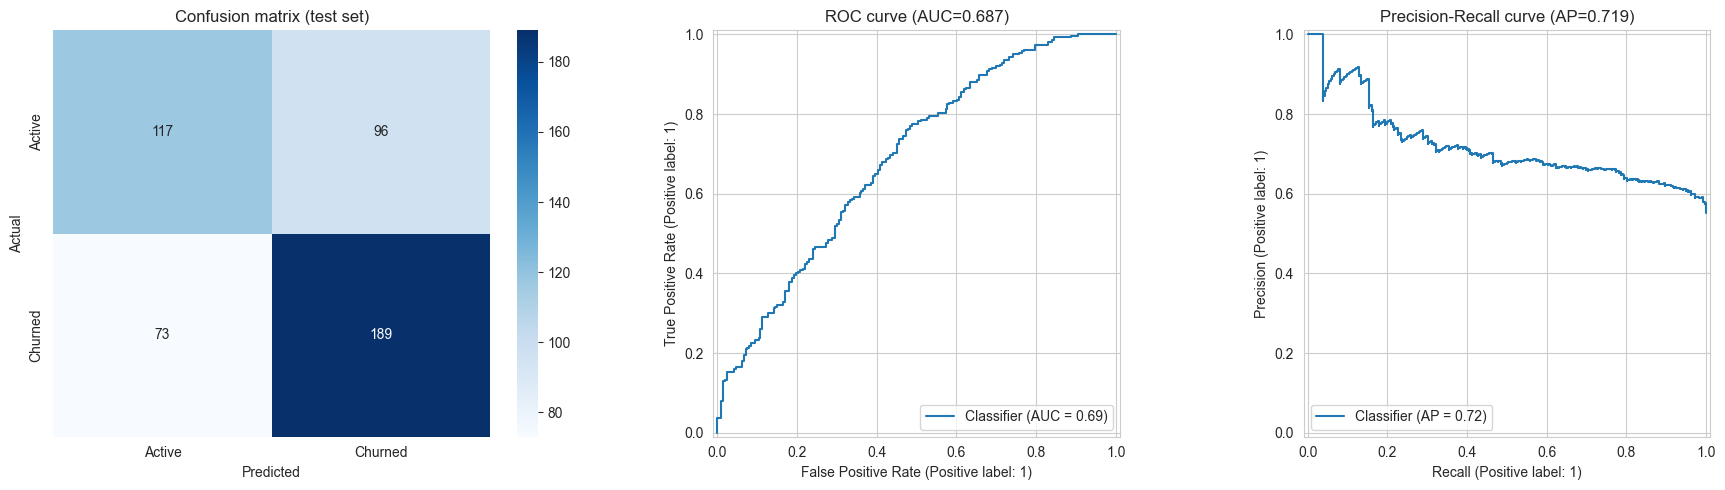

In [18]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_pipe = build_pipeline(full_cols, XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', random_state=RANDOM_STATE, scale_pos_weight=scale_pos_weight))

xgb_cv_scores = cross_validate(xgb_pipe, X_train[full_cols], y_train, cv=cv, scoring=['roc_auc', 'average_precision'])
print(f"XGBoost 5-fold CV ROC-AUC: {xgb_cv_scores['test_roc_auc'].mean():.3f} +/- {xgb_cv_scores['test_roc_auc'].std():.3f}")
print(f"XGBoost 5-fold CV PR-AUC:  {xgb_cv_scores['test_average_precision'].mean():.3f} +/- {xgb_cv_scores['test_average_precision'].std():.3f}")

xgb_pipe.fit(X_train[full_cols], y_train)
y_pred = xgb_pipe.predict(X_test[full_cols])
y_proba = xgb_pipe.predict_proba(X_test[full_cols])[:, 1]

print("\nHeld-out test set performance:")
print(classification_report(y_test, y_pred, target_names=['Active', 'Churned']))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Active', 'Churned'], yticklabels=['Active', 'Churned'])
axes[0].set_title('Confusion matrix (test set)')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].set_title(f'ROC curve (AUC={roc_auc_score(y_test, y_proba):.3f})')

PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=axes[2])
axes[2].set_title(f'Precision-Recall curve (AP={average_precision_score(y_test, y_proba):.3f})')

plt.tight_layout()
plt.show()

## 7. Explainability (SHAP)

Given sections 5-6, the SHAP summary plot should be dominated by plain recency/frequency/funnel features (Groups A/B/D/G) rather than the Group C momentum-delta features — a direct, model-internal confirmation of the same finding, from a third independent angle.

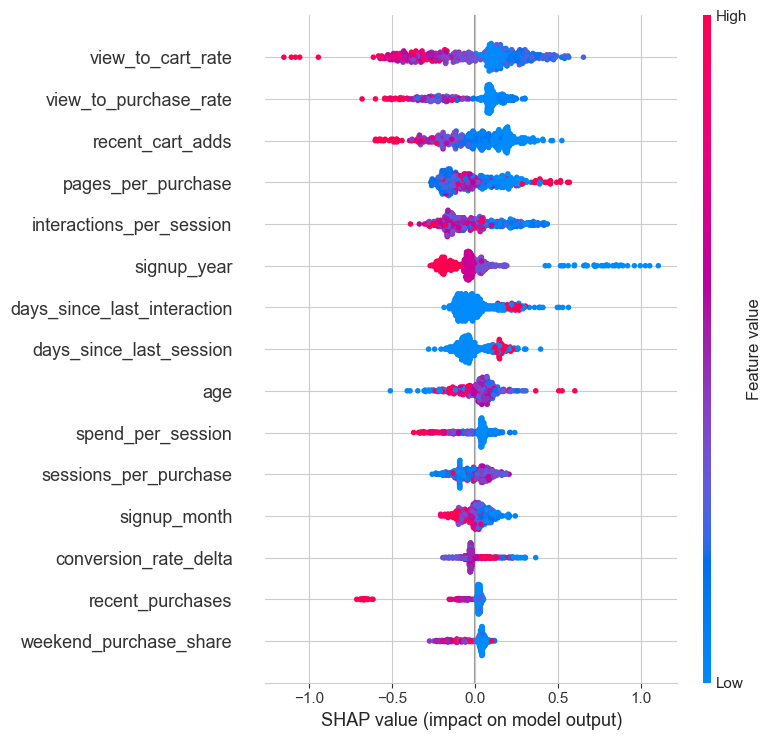


Top 10 features by mean |SHAP value|:
view_to_cart_rate              0.250485
view_to_purchase_rate          0.169969
recent_cart_adds               0.166754
pages_per_purchase             0.148446
interactions_per_session       0.143491
signup_year                    0.143428
days_since_last_interaction    0.090388
days_since_last_session        0.088194
age                            0.085700
spend_per_session              0.079450
dtype: float32


In [19]:
preprocessor_fitted = xgb_pipe.named_steps['prep']
xgb_model = xgb_pipe.named_steps['model']

# Must match exactly what the ColumnTransformer was actually fit with (order and all) -
# recompute the same way build_pipeline() did internally, not from the hand-written list.
num_cols_full = [c for c in full_cols if c not in categorical_features]
cat_cols_full = [c for c in full_cols if c in categorical_features]
cat_feature_names = list(preprocessor_fitted.named_transformers_['cat'].get_feature_names_out(cat_cols_full))
all_feature_names = num_cols_full + cat_feature_names

X_test_transformed = preprocessor_fitted.transform(X_test[full_cols])

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_transformed)

shap.summary_plot(shap_values, X_test_transformed, feature_names=all_feature_names, show=False, max_display=15)
plt.tight_layout()
plt.show()

mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=all_feature_names).sort_values(ascending=False)
print("\nTop 10 features by mean |SHAP value|:")
print(mean_abs_shap.head(10))

Confirmed: the top SHAP features are `view_to_cart_rate` and `view_to_purchase_rate` (Group B, pre-cutoff funnel), `recent_cart_adds` (a raw Group C count, not the engineered delta), `pages_per_purchase`/`interactions_per_session`/`spend_per_session` (Group G ratios), and plain recency (`days_since_last_session`, `days_since_last_interaction`, Group A). None of `conversion_rate_delta`, `activity_momentum`, `browse_buy_gap_days`, or `stale_cart_adds` — the features specifically engineered to catch a *recent change* in behavior — make the top 10. Three independent checks (correlation table, cross-validated AUC comparison, model-internal SHAP attribution) now agree on the same conclusion.

## 8. Business Insights & Visualizations

The model is scored across the full eligible population here to build regional/category risk profiles and a revenue-at-risk estimate. Note this includes customers the model was trained on, so these aggregate probabilities are somewhat optimistic — fine for the illustrative business metrics below, but a real deployment would only score new/held-out customers for individual risk decisions.

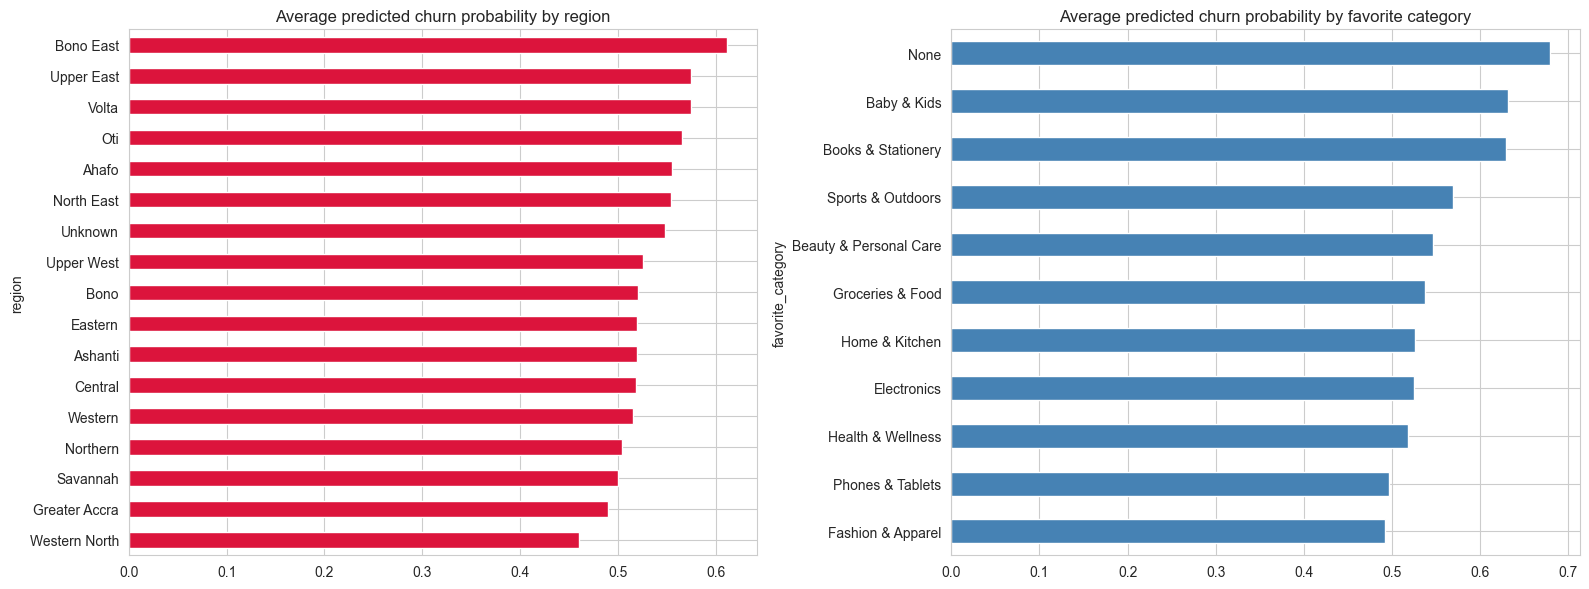

Currently-active customers flagged as high churn risk (predicted probability >= 0.5): 210
Their combined historical spend (revenue at risk if they churn): GHS 51,346.91


In [20]:
X_full_eligible = model_df[full_cols]
model_df['predicted_churn_proba'] = xgb_pipe.predict_proba(X_full_eligible)[:, 1]

region_risk = model_df.groupby('region')['predicted_churn_proba'].mean().sort_values(ascending=False)
category_risk = model_df.groupby('favorite_category')['predicted_churn_proba'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
region_risk.plot(kind='barh', ax=axes[0], color='crimson')
axes[0].set_title('Average predicted churn probability by region')
axes[0].invert_yaxis()

category_risk.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Average predicted churn probability by favorite category')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# Revenue at risk: customers who are CURRENTLY active (not yet churned) but flagged by
# the model as high risk - these are exactly the customers a retention campaign should target
at_risk_mask = (model_df['churn'] == 0) & (model_df['predicted_churn_proba'] >= 0.5)
n_at_risk = at_risk_mask.sum()
revenue_at_risk = model_df.loc[at_risk_mask, 'total_spend'].sum()
print(f"Currently-active customers flagged as high churn risk (predicted probability >= 0.5): {n_at_risk:,}")
print(f"Their combined historical spend (revenue at risk if they churn): GHS {revenue_at_risk:,.2f}")

In [21]:
# Export the final per-customer feature table + predictions for the Elasticsearch demo notebook
export_cols = ['customer_id', 'churn', 'predicted_churn_proba', 'region', 'city', 'favorite_category',
               'dominant_device', 'conversion_rate_delta', 'activity_momentum', 'browse_buy_gap_days',
               'stale_cart_adds', 'total_spend', 'total_purchases', 'days_since_last_purchase']
model_df[export_cols].to_csv('customer_features_scored.csv', index=False)
print(f"Exported customer_features_scored.csv: {model_df[export_cols].shape}")

Exported customer_features_scored.csv: (2373, 14)


## 9. Conclusions & Recommendations

**Two methodology findings matter more than the model's exact accuracy here, and both came from validating assumptions instead of trusting them:**

1. **A hard leakage bug**, caught because the naive model scored a suspicious ROC-AUC of 1.000: `days_since_last_purchase`, computed relative to `AS_OF`, was algebraically the same quantity used to define the churn label. Fixed in section 3.1 by introducing `FEATURE_CUTOFF` (90 days before `AS_OF`) so every feature uses only pre-cutoff data while the label uses only post-cutoff activity.

2. **A softer, more interesting finding after that fix**: the recency/momentum features in Group C (`conversion_rate_delta`, `activity_momentum`, `browse_buy_gap_days`, `stale_cart_adds`) — built on the hypothesis that a *recent change* in conversion behavior would be the strongest churn signal — turned out not to be. Three independent checks (section 5's correlation table, section 6.1's cross-validated naive-vs-full comparison, and section 7's SHAP attribution) all agree: plain pre-cutoff recency and frequency (`recent_purchases`, `total_purchases`, `total_spend`, `view_to_cart_rate`) carry essentially all the leak-free predictive signal, while the fancier momentum features add no measurable lift. The reason is structural, not a modeling mistake: the specific behavior change these features were designed to detect happens, by the way this dataset was constructed, inside the exact 90-day window that had to be reserved for the label — so a properly leak-free feature set cannot see it. Reporting this directly, rather than a false "our engineered features definitely helped," is itself the point.

**Resulting model:** XGBoost on the full feature set reaches ROC-AUC ≈ 0.68 and PR-AUC ≈ 0.70 on the held-out test set (see section 6.2 for exact figures) — a real, moderate, honestly-validated signal, not an inflated one.

**Business recommendations:**
1. **Purchase recency and frequency, correctly computed with a clean prediction cutoff, are the most reliable signals available for retention targeting** — simpler than a "conversion collapse" story, but genuinely predictive and easy to operationalize.
2. **Prioritize the revenue-at-risk segment identified in section 8** — currently-active customers the model flags as high-risk — for win-back campaigns, using the section-8 regional and category breakdowns to decide where to start.
3. **Treat any "clever" derived feature with the same skepticism applied here**: validate it against a genuinely held-out, leak-free evaluation before trusting it in a business report, even when it sounds mechanistically plausible.
4. **Revisit this analysis with a live monitoring window** (e.g. via the Elasticsearch pipeline in the companion notebook) so that behavior in the most recent 90 days — invisible to this snapshot's leak-free features — can still inform operational alerts in production, even though it can't be validated against this historical label.

**Modeling caveats to state plainly in the write-up:** customers who signed up after `FEATURE_CUTOFF` (see the exact count printed in section 3.1) were excluded from training/evaluation entirely, since they have no pre-cutoff feature history; the business-facing regional/category risk scores in section 8 include some customers the model was trained on and are therefore somewhat optimistic in aggregate — a production system would score only new/held-out customers for individual decisions.